# HSI and Synthetic Data

## Load data and libraries

In [50]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

# Import necessary packages and libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as sp
import graphlearning as gl
from scipy.special import jn
import scipy.sparse as sps
import scipy.sparse.linalg as spla
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.ndimage import gaussian_filter
from itertools import product
from joblib import Parallel, delayed
from scipy.optimize import nnls
from sklearn.decomposition import PCA
from tabulate import tabulate

# Import functions from Chen et. al.
from graph_active_learning_functions import *

In [51]:
# Constants
iters = 100
samples = 2500
samples_linear = 2000

# Load datasets

# Urban
X_urban, S_urban, A_urban = load_data(name = 'processed_data/processed_data/urban/urban_processed_data.npy', typename = 'HSI', sample = True, H = 307, W = 307)

# Samson
X_samson, S_samson, A_samson = load_data(name = 'processed_data/processed_data/samson/samson_processed_data.npy', typename = 'HSI', sample = True, H = 95, W = 95)    

# Jasper
X_jasper, S_jasper, A_jasper = load_data(name = 'processed_data/processed_data/jasper/jasper_processed_data.npy', typename = 'HSI', sample = True, H = 100, W = 100)    

# Apex
X_apex, S_apex, A_apex = load_data(name = 'processed_data/processed_data/apex/apex_processed_data.npy', typename = 'HSI', sample = True, H = 111, W = 122)    

# Nonlinear Synthetic
X_nl_flat, S_gt_nl, A_gt_nl = load_data(name = 'my_custom_dataset.npy', typename = 'nonlinear')

# Linear Synthetic
X_linear, S_linear, A_linear = synthetic_linear_data(samples = 2000, channels = 300)


Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (162, 94249)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])
X (reshaped): (162, 2500)
Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <class 'numpy.ndarray'>
Shape of X: (156, 9025)

Type of A: <class 'dict'>
Keys inside A: dict_keys(['A_ref', 'A_fclsu', 'A_MBO', 'A_graphL', 'A_MSC', 'A_qmv', 'A_nmf', 'A_EGU'])

Type of S: <class 'dict'>
Keys inside S: dict_keys(['S_ref', 'S_fclsu', 'S_MBO', 'S_graphL', 'S_MSC', 'S_qmv', 'S_nmf', 'S_EGU'])
X (reshaped): (156, 2500)
Keys in the dataset: dict_keys(['A', 'S', 'err_all', 'X', 'dataset', 'shape', 't_MSC', 't_EGU'])
Type of X: <cl

## Min RMSE

### Urban

#### Tests

##### Param Test results

In [3]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 16.515091863060118
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 16.515091863060118
#  SAD: 6.27405089498243


# GLU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 20.604754586570657
# Best alpha: 20
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 16.515091863060118
#  SAD: 4.08966272351054

# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 15.091276758936765
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 15.091276758936765
#  SAD: 11.700478855063887

# GLU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 24.804641262486346
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 15.091276758936765
#  SAD: 9.713364503549581


# GRSU (OH) (RMSE)
# ==========
# Best RMSE: 12.773405185407343
# Best alpha: 10
# Best lambda: 100
# Best gamma: 0.1
# Best rho: 0.1
# RMSE: 12.773405185407343
#  SAD: 6.685335455213946


# GRSU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 18.647888671426852
# Best alpha: 20
# Best lambda: 10
# Best gamma: 0.01
# Best rho: 0.1
# RMSE: 14.545952828433787
#  SAD: 4.101935842993066

# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 11.944299921789318
# Best alpha: 50
# Best lambda: 5
# Best gamma: 100.0
# Best rho: 1.0
# RMSE: 11.944299921789318
#  SAD: 9.594314161215735

# GRSU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 21.499243045176836
# Best alpha: 50
# Best lambda: 10
# Best gamma: 100.0
# Best rho: 10.0
# RMSE: 12.120692338987968
#  SAD: 9.378550706188868



# ALMM
# ==========
# Best RMSE: 13.301049781939097
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.5e-06
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055


# Graph ALMM (RMSE)
# ==========
# Best RMSE: 8.225441441655992
# Best alpha: 0.0055
# Best M_total: 40.0
# Best xi: 10
# Best label: Exact


# Graph ALMM (RMSE + SAD)
# ==========
# Best RMSE + SAD: 15.879516366633172
# Best alpha: 0.0055
# Best M_total: 40.0
# Best xi: 100
# Best label: Exact


##### Runs

In [67]:
# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 15.091276758936765
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 15.091276758936765
#  SAD: 11.700478855063887

# Actual Run
A_GLU_urban, S_GLU_urban, A_GLU_RMSE_urban, S_GLU_RMSE_urban = run_unmixing_pipeline_example(X = X_urban, A_gt = A_urban, S_gt = S_urban, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 4, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Urban Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_urban_energy, __, __, __ = run_unmixing_pipeline_example(X = X_urban, A_gt = A_urban, S_gt = S_urban, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 4, 
                                                                                         print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Urban Data", 
                                                                                         prep = None, array_plots = True)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 15.091276758936765
Final Endmember SAD: 11.700478855063887


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 11.944299921789318
Final Endmember SAD: 9.594314161215735


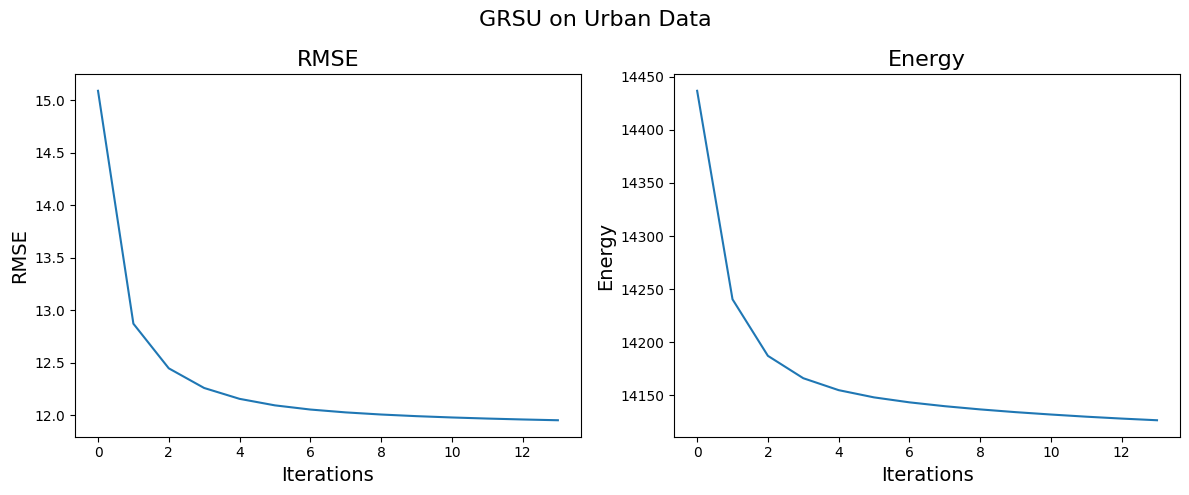

In [5]:
# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 11.944299921789318
# Best alpha: 50
# Best lambda: 5
# Best gamma: 100.0
# Best rho: 1.0
# RMSE: 11.944299921789318
#  SAD: 9.594314161215735

# Actual Run
A_GRSU_urban, S_GRSU_urban, A_GRSU_RMSE_urban, S_GRSU_RMSE_urban = run_unmixing_pipeline_example(X = X_urban, A_gt = A_urban, S_gt = S_urban, 
                                                                                         N = samples, iters = iters, alpha = 50.0, lam = 5.0, gamma = 100.0, rho = 1.0, m_0 = 4, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on Urban Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_urban_RMSE, GRSU_urban_energy, __, __ = run_unmixing_pipeline_example(X = X_urban, A_gt = A_urban, S_gt = S_urban, 
                                                                        N = samples, iters = iters, alpha = 50.0, lam = 5.0, gamma = 100.0, rho = 1.0, m_0 = 4, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Urban Data", 
                                                                        prep = None, array_plots = True)

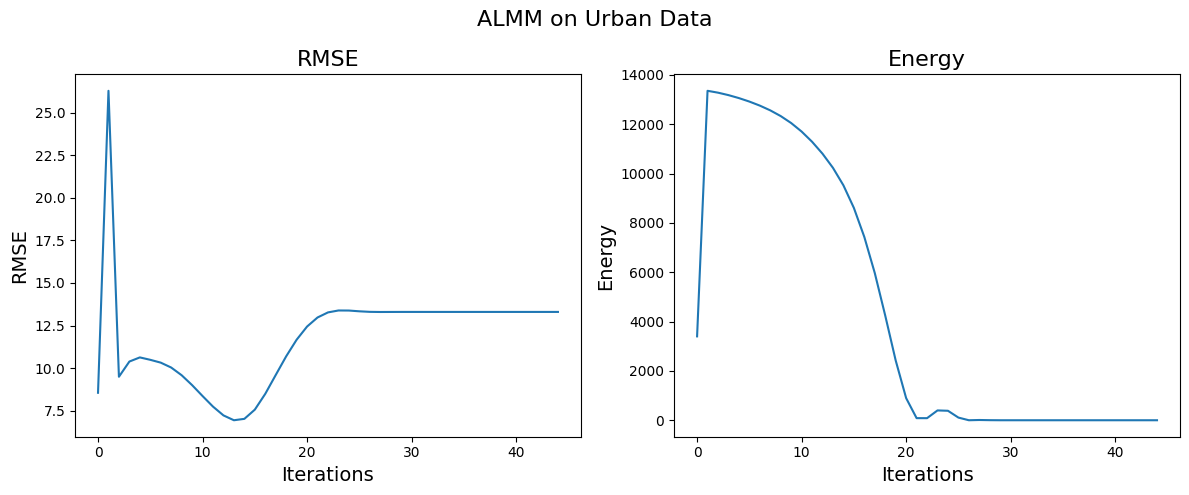

In [6]:
# ALMM
# ==========
# Best RMSE: 13.301049781939097
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.5e-06
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055

best_alpha = 5.5e-5
best_beta = 5.5e-6
best_gamma = 5.5e-7
best_eta = 0.0055

# Actual Run
E_ALMM_urban, A_ALMM_urban, T_ALMM_urban, B_ALMM_urban = algo_2_almm_optimized(X = X_urban, S = S_urban, A_gt = A_urban, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on Urban Data", array_plots = False)

# Error and Energy arrays
ALMM_urban_RMSE, ALMM_urban_energy, __, __ = algo_2_almm_optimized(X = X_urban, S = S_urban, A_gt = A_urban, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Urban Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (162, 4)
Final Abundance RMSE: 8.225441441655992
Final Endmember SAD: 12.096192777177107


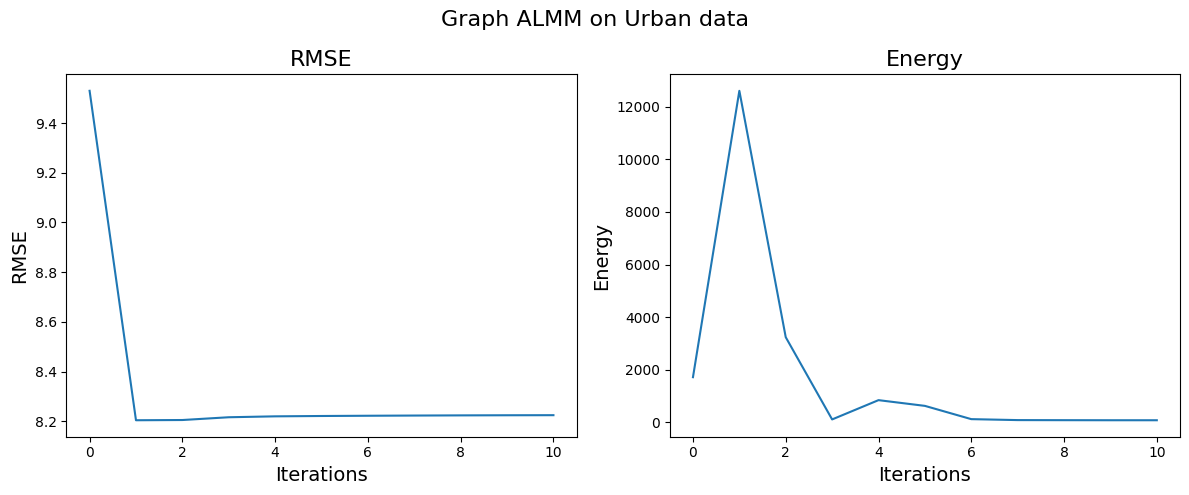

In [7]:
# Graph ALMM (RMSE)
# ==========
# Best RMSE: 8.225441441655992
# Best alpha: 0.0055
# Best M_total: 40.0
# Best xi: 10
# Best label: Exact

alpha_0 = 0.0055
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 10

# Actual Run
A_graph_almm_urban, S_graph_almm_urban, A_rmse_graph_almm_urban, S_rmse_graph_almm_urban = run_unmixing_pipeline_example2(X = X_urban, A_gt = A_urban, S_gt = S_urban, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 4, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on Urban data", array_plots = False)

# Error and Energy arrays
graph_almm_urban_RMSE, graph_almm_urban_energy, __, __ = run_unmixing_pipeline_example2(X = X_urban, A_gt = A_urban, S_gt = S_urban, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 4, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Urban data", array_plots = True)

#### Plots

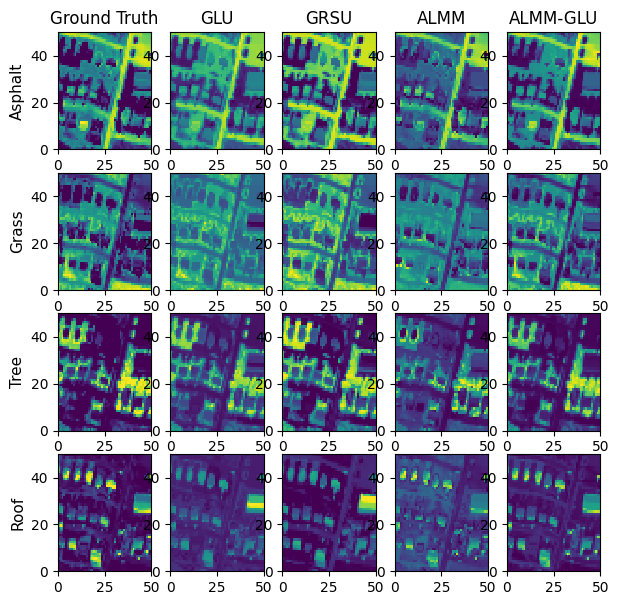

In [9]:
class_names = ['Asphalt', 'Grass', 'Tree', 'Roof']
algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM', 'ALMM-GLU']

image_plotting(A_gt = A_urban, A_f_GLU = A_GLU_urban, A_f_GRSU = A_GRSU_urban, A_f_ALMM = A_ALMM_urban, A_f_Graph_ALMM = A_graph_almm_urban, 
               k = 4, col = 5, patch_size = 50, class_names = class_names, algo_names = algo_names)

#### Error and Energy plots

In [68]:
# Define data arrays of tuples
urban_RMSE = [
    ("GLU", A_GLU_RMSE_urban),
    ("GRSU", GRSU_urban_RMSE),
    ("ALMM", ALMM_urban_RMSE),
    ("Graph-ALMM", graph_almm_urban_RMSE),
]

urban_energy = [
    ("GLU", GLU_urban_energy),
    ("GRSU", GRSU_urban_energy),
    ("ALMM", ALMM_urban_energy),
    ("Graph-ALMM", graph_almm_urban_energy),
]

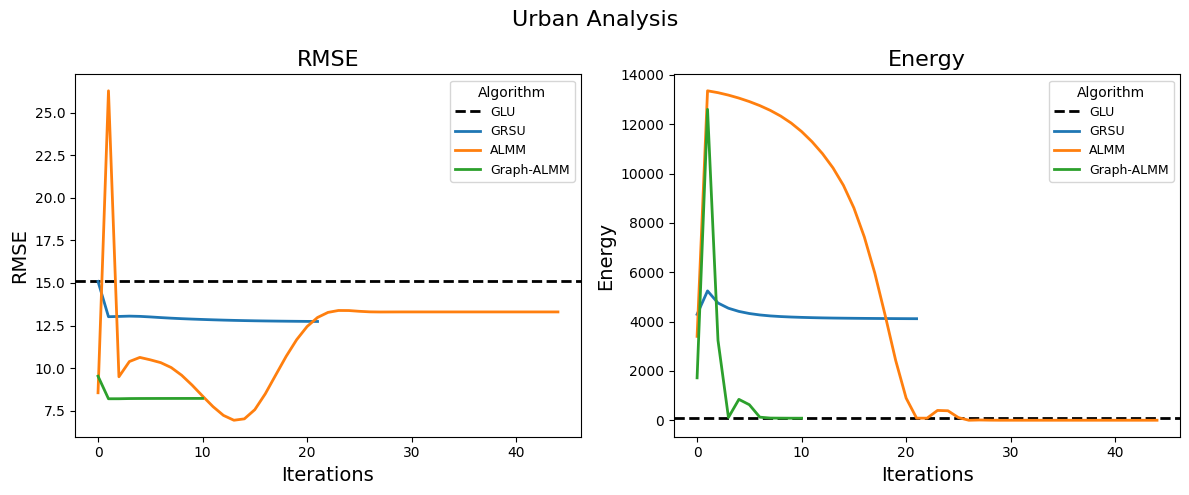

In [69]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = urban_RMSE, Energy_data = urban_energy, title_0 = "Urban Analysis")

### Samson

#### Tests

##### Param Test results

In [ ]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 6.705644898408177
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 6.705644898408177
#  SAD: 25.676675966836008


# GLU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 32.38232086524418
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 6.705644898408177
#  SAD: 25.676675966836008

# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 4.48668375677853
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 4.48668375677853
#  SAD: 16.461629559993924

# GLU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 20.948313316772452
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 4.48668375677853
#  SAD: 16.461629559993924


# GRSU (OH) (RMSE)
# ==========
# Best RMSE: 4.0146045032947875
# Best alpha: 10
# Best lambda: 10
# Best gamma: 0.1
# Best rho: 0.1
# RMSE: 4.0146045032947875
#  SAD: 30.791804685609783


# GRSU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 16.69564045484936
# Best alpha: 100
# Best lambda: 1000
# Best gamma: 1.0
# Best rho: 1.0
# RMSE: 6.301012269285211
#  SAD: 10.39462818556415

# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 3.177697436003959
# Best alpha: 20
# Best lambda: 50
# Best gamma: 1.0
# Best rho: 1.0
# RMSE: 3.177697436003959
#  SAD: 27.935363359731912

# GRSU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 17.074063680794822
# Best alpha: 20
# Best lambda: 100
# Best gamma: 0.1
# Best rho: 0.01
# RMSE: 6.414453124169384
#  SAD: 10.65961055662544


# ALMM
# ==========
# Best RMSE: 5.178170657048993
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07


# Graph ALMM (RMSE)
# ==========
# Best RMSE: 2.010358988346232
# Best alpha: 0.0055
# Best M_total: 40.0
# Best xi: 1
# Best label: Exact


# Graph ALMM (RMSE + SAD)
# ==========
# Best RMSE + SAD: 21.204961212912274
# Best alpha: 0.0055
# Best M_total: 20.0
# Best xi: 10
# Best label: Exact



##### Runs

In [70]:
# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 4.48668375677853
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 4.48668375677853
#  SAD: 16.461629559993924

# Actual Run
A_GLU_samson, S_GLU_samson, A_GLU_RMSE_samson, S_GLU_RMSE_samson = run_unmixing_pipeline_example(X = X_samson, A_gt = A_samson, S_gt = S_samson, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 3, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Samson Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_samson_energy, __, __, __ = run_unmixing_pipeline_example(X = X_samson, A_gt = A_samson, S_gt = S_samson, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 3, 
                                                                                         print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Samson Data", 
                                                                                         prep = None, array_plots = True)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (3, 2500)
Final End-member Matrix Shape: (156, 3)
Final Abundance RMSE: 4.48668375677853
Final Endmember SAD: 16.461629559993924


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (3, 2500)
Final End-member Matrix Shape: (156, 3)
Final Abundance RMSE: 3.177697436003959
Final Endmember SAD: 27.935363359731912


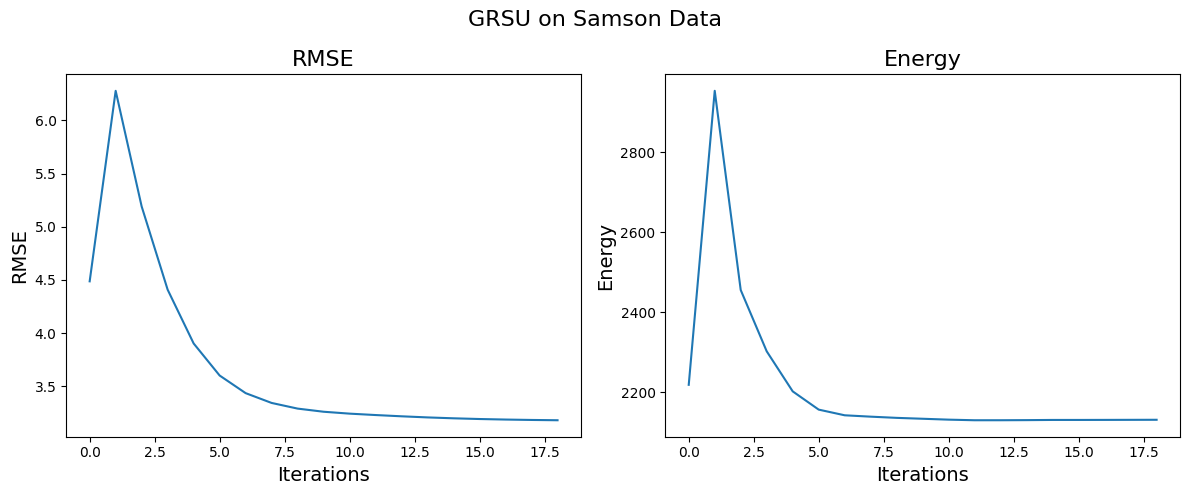

In [19]:
# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 3.177697436003959
# Best alpha: 20
# Best lambda: 50
# Best gamma: 1.0
# Best rho: 1.0
# RMSE: 3.177697436003959
#  SAD: 27.935363359731912

# Actual Run
A_GRSU_samson, S_GRSU_samson, A_GRSU_RMSE_samson, S_GRSU_RMSE_samson = run_unmixing_pipeline_example(X = X_samson, A_gt = A_samson, S_gt = S_samson, 
                                                                                         N = samples, iters = iters, alpha = 20.0, lam = 50.0, gamma = 1.0, rho = 1.0, m_0 = 3, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on Samson Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_samson_RMSE, GRSU_samson_energy, __, __ = run_unmixing_pipeline_example(X = X_samson, A_gt = A_samson, S_gt = S_samson, 
                                                                        N = samples, iters = iters, alpha = 20.0, lam = 50.0, gamma = 1.0, rho = 1.0, m_0 = 3, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Samson Data", 
                                                                        prep = None, array_plots = True)

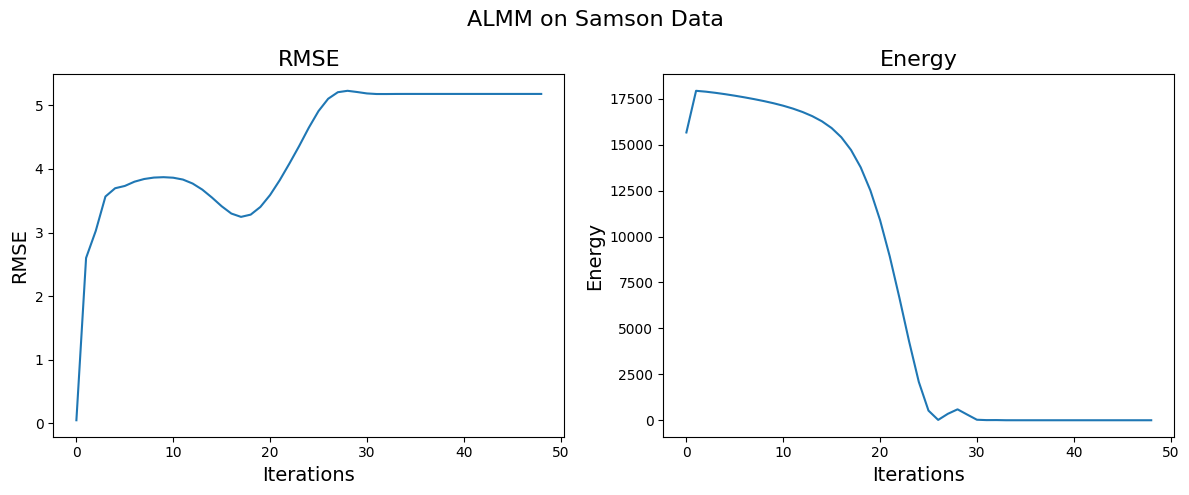

In [73]:
# ALMM
# ==========
# Best RMSE: 5.178170657048993
# Best alpha: 5.4999999999999995e-05
# Best beta: 5.499999999999999e-07
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

best_alpha = 5.5e-5
best_beta = 5.5e-7
best_gamma = 5.5e-7
best_eta = 5.5e-7

# Actual Run
E_ALMM_samson, A_ALMM_samson, T_ALMM_samson, B_ALMM_samson = algo_2_almm_optimized(X = X_samson, S = S_samson, A_gt = A_samson, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on Samson Data", array_plots = False)

# Error and Energy arrays
ALMM_samson_RMSE, ALMM_samson_energy, __, __ = algo_2_almm_optimized(X = X_samson, S = S_samson, A_gt = A_samson, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Samson Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (3, 2500)
Final End-member Matrix Shape: (156, 3)
Final Abundance RMSE: 2.010358988346232
Final Endmember SAD: 37.46595557721749


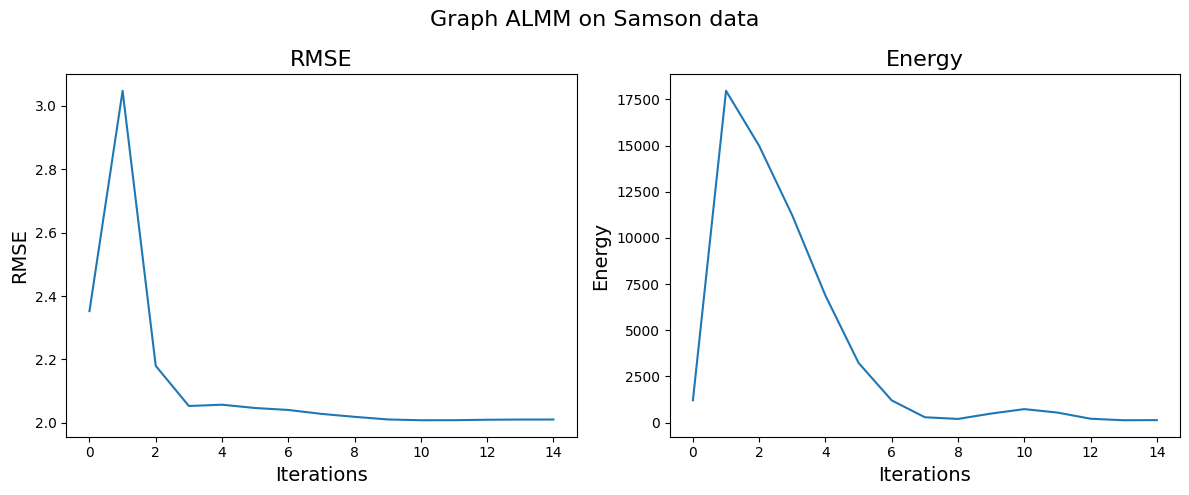

In [74]:
# Graph ALMM (RMSE)
# ==========
# Best RMSE: 2.010358988346232
# Best alpha: 0.0055
# Best M_total: 40.0
# Best xi: 1
# Best label: Exact

alpha_0 = 0.0055
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1

# Actual Run
A_graph_almm_samson, S_graph_almm_samson, A_rmse_graph_almm_samson, S_rmse_graph_almm_samson = run_unmixing_pipeline_example2(X = X_samson, A_gt = A_samson, S_gt = S_samson, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 3, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on Samson data", array_plots = False)

# Error and Energy arrays
graph_almm_samson_RMSE, graph_almm_samson_energy, __, __ = run_unmixing_pipeline_example2(X = X_samson, A_gt = A_samson, S_gt = S_samson, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 3, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Samson data", array_plots = True)

#### Plots

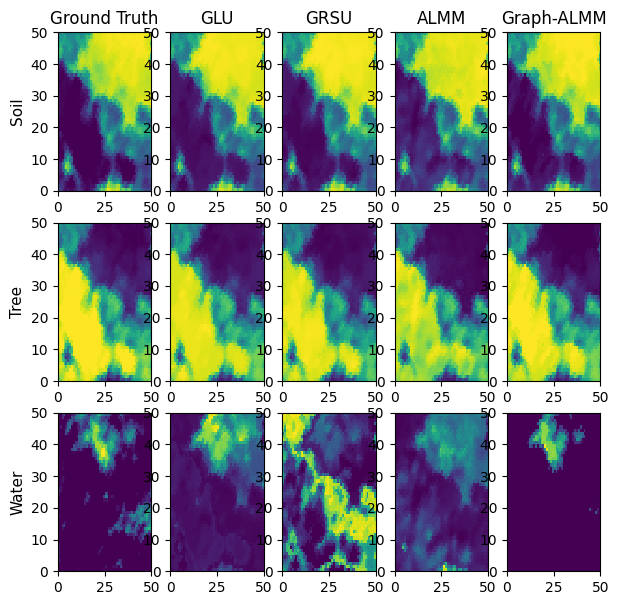

In [22]:
class_names = ['Soil', 'Tree', 'Water']
algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM', 'Graph-ALMM']

image_plotting(A_gt = A_samson, A_f_GLU = A_GLU_samson, A_f_GRSU = A_GRSU_samson, A_f_ALMM = A_ALMM_samson, A_f_Graph_ALMM = A_graph_almm_samson, 
               k = 3, col = 5, patch_size = 50, class_names = class_names, algo_names = algo_names)

#### Error and Energy plots

In [75]:
# Define data arrays of tuples
samson_RMSE = [
    ("GLU", A_GLU_RMSE_samson),
    ("GRSU", GRSU_samson_RMSE),
    ("ALMM", ALMM_samson_RMSE),
    ("Graph-ALMM", graph_almm_samson_RMSE),
]

samson_energy = [
    ("GLU", GLU_samson_energy),
    ("GRSU", GRSU_samson_energy),
    ("ALMM", ALMM_samson_energy),
    ("Graph-ALMM", graph_almm_samson_energy),
]

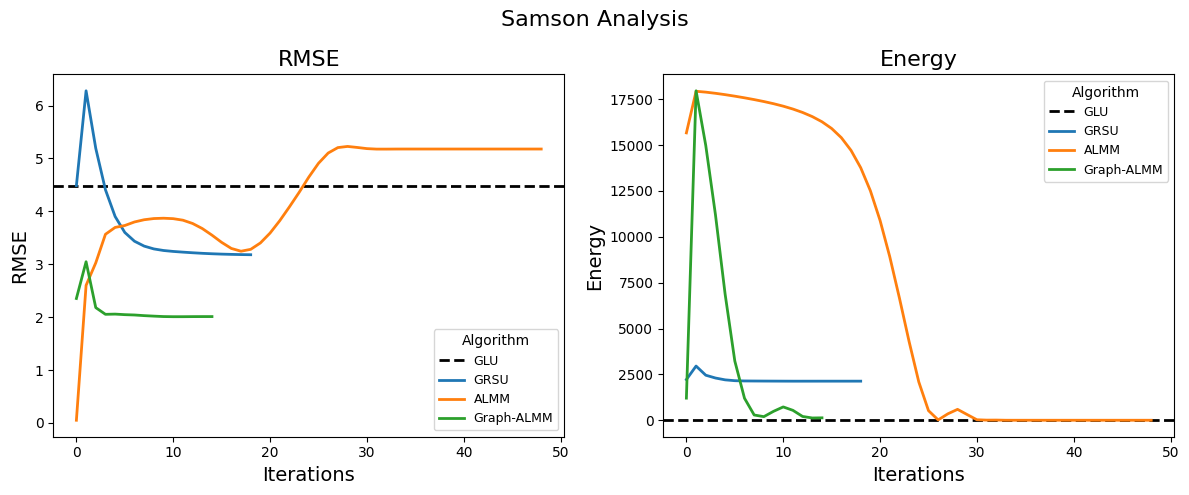

In [76]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = samson_RMSE, Energy_data = samson_energy, title_0 = "Samson Analysis")

### Jasper Ridge

#### Tests

##### Param Test results

In [ ]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 10.783719783844907
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 10.783719783844907
#  SAD: 8.43143426694995


# GLU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 17.45981403250206
# Best alpha: 20
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 10.783719783844907
#  SAD: 6.676094248657153

# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 13.395562298512884
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 13.395562298512884
#  SAD: 9.30356727760364

# GLU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 21.427111061315582
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 13.395562298512884
#  SAD: 8.031548762802698


# GRSU (OH) (RMSE)
# ==========
# Best RMSE: 7.874485848794502
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 1.0
# RMSE: 7.874485848794502
#  SAD: 5.331227681041914


# GRSU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 13.122836837262442
# Best alpha: 10
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 1.0
# RMSE: 7.875529010734364
#  SAD: 5.247307826528078

# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 6.358587865401678
# Best alpha: 100
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 1.0
# RMSE: 6.358587865401678
#  SAD: 7.995656947729099

# GRSU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 14.18297409740865
# Best alpha: 20
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 1.0
# RMSE: 6.513450668466827
#  SAD: 7.669523428941822

# ALMM
# ==========
# Best RMSE: 13.620656133998784
# Best alpha: 0.0005499999999999999
# Best beta: 0.0055
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055


# Graph ALMM (RMSE)
# ==========
# Best RMSE: 6.872974138791582
# Best alpha: 5.499999999999999e-07
# Best M_total: 40.0
# Best xi: 1
# Best label: OH


# Graph ALMM (RMSE + SAD)
# ==========
# Best RMSE + SAD: 18.7813615364318
# Best alpha: 0.0055
# Best M_total: 40.0
# Best xi: 100
# Best label: Exact



##### Runs

In [83]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 10.783719783844907
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 10.783719783844907
#  SAD: 8.43143426694995

# Actual Run
A_GLU_jasper, S_GLU_jasper, A_GLU_RMSE_jasper, S_GLU_RMSE_jasper = run_unmixing_pipeline_example(X = X_jasper, A_gt = A_jasper, S_gt = S_jasper, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 4, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Jasper Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_jasper_energy, __, __, __ = run_unmixing_pipeline_example(X = X_jasper, A_gt = A_jasper, S_gt = S_jasper, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 4, 
                                                                                         print_bool = False, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Jasper Data", 
                                                                                         prep = None, array_plots = True)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (198, 4)
Final Abundance RMSE: 10.783719783844907
Final Endmember SAD: 8.43143426694995


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (198, 4)
Final Abundance RMSE: 6.358587865401678
Final Endmember SAD: 7.995656947729099


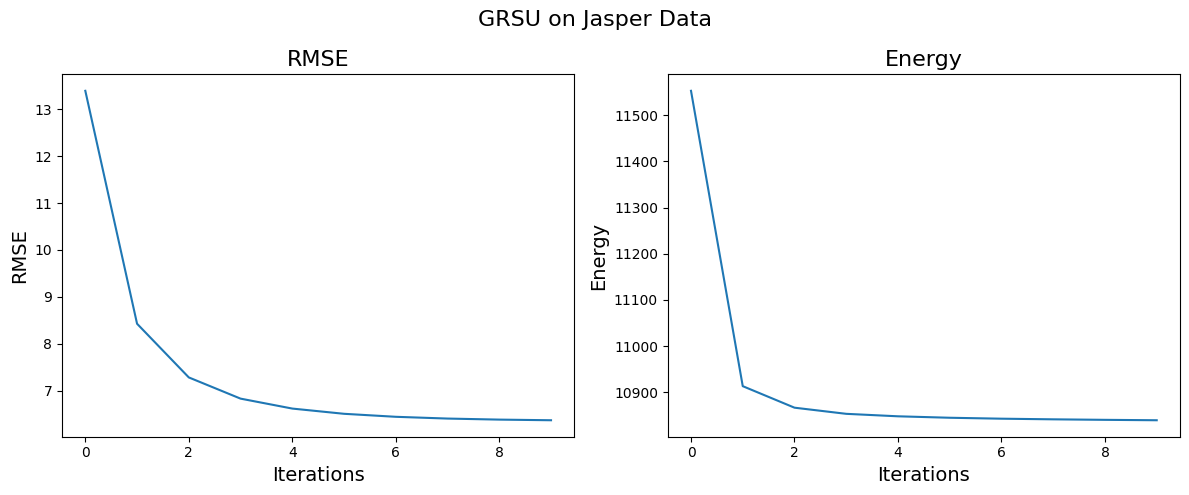

In [79]:
# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 6.358587865401678
# Best alpha: 100
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 1.0
# RMSE: 6.358587865401678
#  SAD: 7.995656947729099

# Actual Run
A_GRSU_jasper, S_GRSU_jasper, A_GRSU_RMSE_jasper, S_GRSU_RMSE_jasper = run_unmixing_pipeline_example(X = X_jasper, A_gt = A_jasper, S_gt = S_jasper, 
                                                                                         N = samples, iters = iters, alpha = 100.0, lam = 1.0, gamma = 100.0, rho = 1.0, m_0 = 4, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on Jasper Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_jasper_RMSE, GRSU_jasper_energy, __, __ = run_unmixing_pipeline_example(X = X_jasper, A_gt = A_jasper, S_gt = S_jasper, 
                                                                        N = samples, iters = iters, alpha = 100.0, lam = 1.0, gamma = 100.0, rho = 1.0, m_0 = 4, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Jasper Data", 
                                                                        prep = None, array_plots = True)

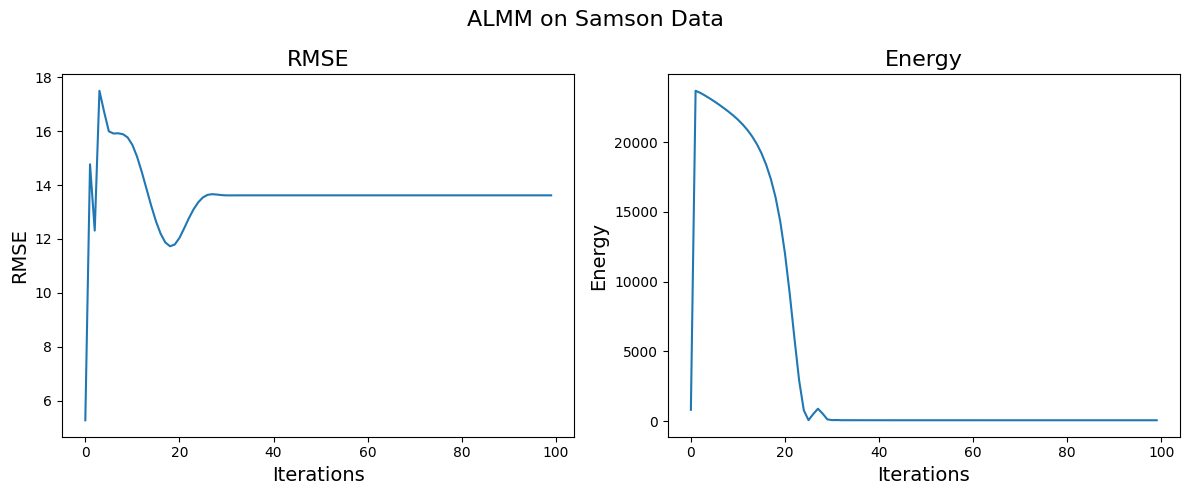

In [80]:
# ALMM
# ==========
# Best RMSE: 13.620656133998784
# Best alpha: 0.0005499999999999999
# Best beta: 0.0055
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055

best_alpha = 0.00055
best_beta = 0.0055
best_gamma = 5.5e-7
best_eta = 0.0055

# Actual Run
E_ALMM_jasper, A_ALMM_jasper, T_ALMM_jasper, B_ALMM_jasper = algo_2_almm_optimized(X = X_jasper, S = S_jasper, A_gt = A_jasper, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on Samson Data", array_plots = False)

# Error and Energy arrays
ALMM_jasper_RMSE, ALMM_jasper_energy, __, __ = algo_2_almm_optimized(X = X_jasper, S = S_jasper, A_gt = A_jasper, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Samson Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (198, 4)
Final Abundance RMSE: 6.872974138791582
Final Endmember SAD: 23.74986319537115


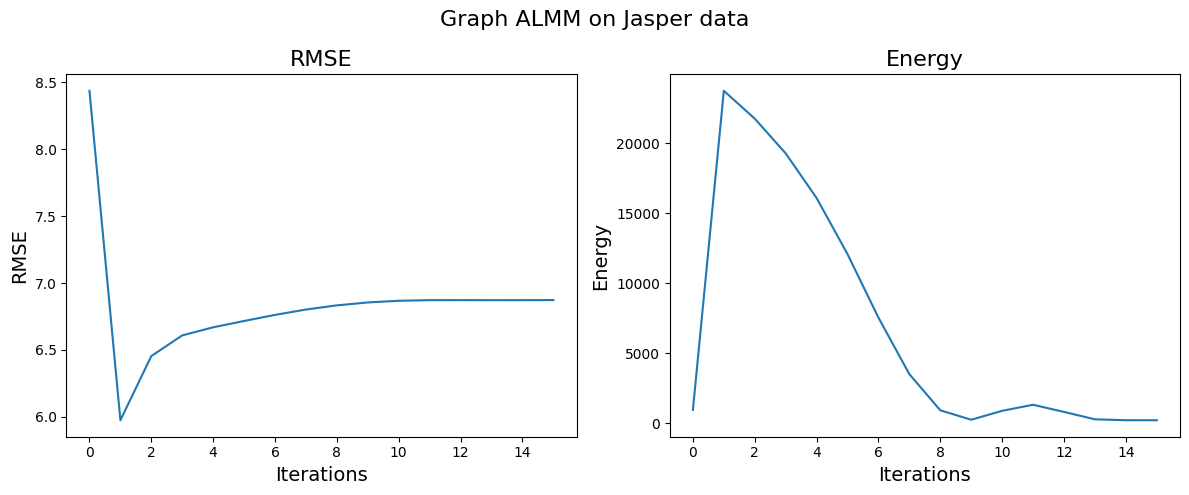

In [81]:
# Graph ALMM (RMSE)
# ==========
# Best RMSE: 6.872974138791582
# Best alpha: 5.499999999999999e-07
# Best M_total: 40.0
# Best xi: 1
# Best label: OH

alpha_0 = 5.5e-7
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1

# Actual Run
A_graph_almm_jasper, S_graph_almm_jasper, A_rmse_graph_almm_jasper, S_rmse_graph_almm_jasper = run_unmixing_pipeline_example2(X = X_jasper, A_gt = A_jasper, S_gt = S_jasper, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 4, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on Jasper data", array_plots = False)

# Error and Energy arrays
graph_almm_jasper_RMSE, graph_almm_jasper_energy, __, __ = run_unmixing_pipeline_example2(X = X_jasper, A_gt = A_jasper, S_gt = S_jasper, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 4, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Jasper data", array_plots = True)

#### Plots

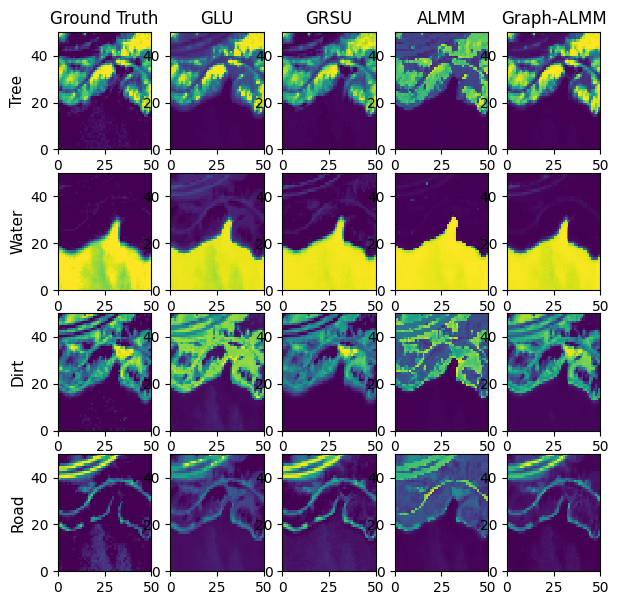

In [29]:
class_names = ['Tree', 'Water', 'Dirt', 'Road']
algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM', 'Graph-ALMM']

image_plotting(A_gt = A_jasper, A_f_GLU = A_GLU_jasper, A_f_GRSU = A_GRSU_jasper, A_f_ALMM = A_ALMM_jasper, A_f_Graph_ALMM = A_graph_almm_jasper, 
               k = 4, col = 5, patch_size = 50, class_names = class_names, algo_names = algo_names)

#### Error and Energy plots

In [84]:
# Define data arrays of tuples
jasper_RMSE = [
    ("GLU", A_GLU_RMSE_jasper),
    ("GRSU", GRSU_jasper_RMSE),
    ("ALMM", ALMM_jasper_RMSE),
    ("Graph-ALMM", graph_almm_jasper_RMSE),
]

jasper_energy = [
    ("GLU", GLU_jasper_energy),
    ("GRSU", GRSU_jasper_energy),
    ("ALMM", ALMM_jasper_energy),
    ("Graph-ALMM", graph_almm_jasper_energy),
]

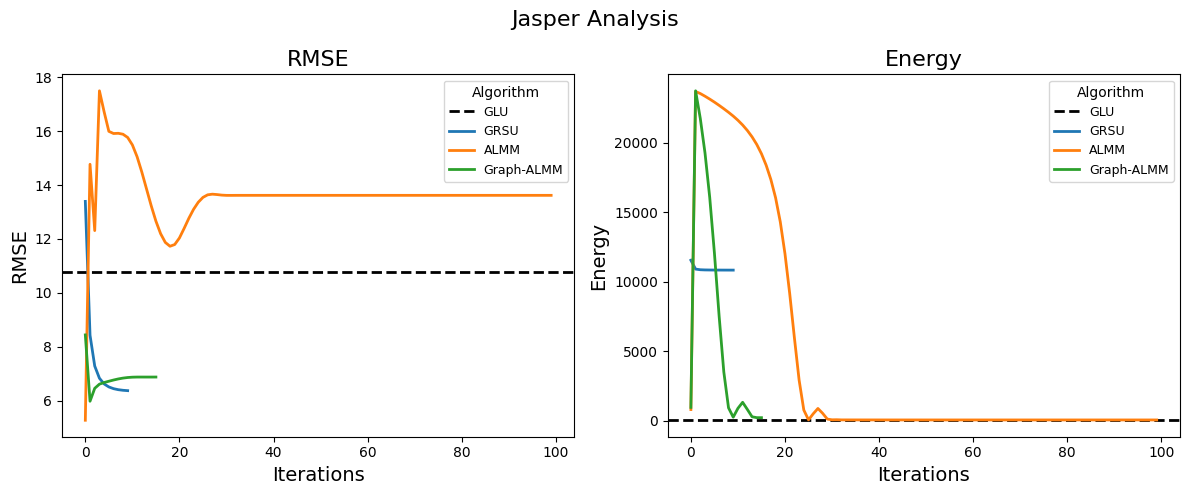

In [86]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = jasper_RMSE, Energy_data = jasper_energy, title_0 = "Jasper Analysis")

### Apex

#### Tests

##### Param Test results

In [ ]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 20.342800377272443
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 20.342800377272443
#  SAD: 27.608475281425953


# GLU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 47.95127565869839
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 20.342800377272443
#  SAD: 27.608475281425953

# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 20.88222042048617
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 20.88222042048617
#  SAD: 39.70450446532521

# GLU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 60.58672488581138
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 20.88222042048617
#  SAD: 39.70450446532521


# GRSU (OH) (RMSE)
# ==========
# Best RMSE: 13.65130520617818
# Best alpha: 10
# Best lambda: 1
# Best gamma: 10.0
# Best rho: 100.0
# RMSE: 13.65130520617818
#  SAD: 27.63435553533374


# GRSU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 37.94048585201743
# Best alpha: 10
# Best lambda: 100
# Best gamma: 10.0
# Best rho: 0.1
# RMSE: 16.15335063742745
#  SAD: 21.787135214589984

# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 11.208067044225308
# Best alpha: 20
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 10.0
# RMSE: 11.208067044225308
#  SAD: 40.76096097652306

# GRSU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 49.68693394526224
# Best alpha: 10
# Best lambda: 1
# Best gamma: 10.0
# Best rho: 10.0
# RMSE: 12.207081805057316
#  SAD: 37.479852140204926

# ALMM
# ==========
# Best RMSE: 22.64309411402312
# Best alpha: 5.499999999999999e-07
# Best beta: 0.0055
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07


# Graph ALMM (RMSE)
# ==========
# Best RMSE: 13.062906030349808
# Best alpha: 0.0055
# Best M_total: 30.0
# Best xi: 1
# Best label: OH


# Graph ALMM (RMSE + SAD)
# ==========
# Best RMSE + SAD: 33.18778805064496
# Best alpha: 0.0055
# Best M_total: 30.0
# Best xi: 100
# Best label: OH



##### Runs

In [87]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 20.342800377272443
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 20.342800377272443
#  SAD: 27.608475281425953

# Actual Run
A_GLU_apex, S_GLU_apex, A_GLU_RMSE_apex, S_GLU_RMSE_apex = run_unmixing_pipeline_example(X = X_apex, A_gt = A_apex, S_gt = S_apex, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 4, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Apex Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_apex_energy, __, __, __ = run_unmixing_pipeline_example(X = X_apex, A_gt = A_apex, S_gt = S_apex, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 4, 
                                                                                         print_bool = False, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Apex Data", 
                                                                                         prep = None, array_plots = True)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (285, 4)
Final Abundance RMSE: 20.342800377272443
Final Endmember SAD: 27.608475281425953


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (285, 4)
Final Abundance RMSE: 11.208067044225308
Final Endmember SAD: 40.76096097652306


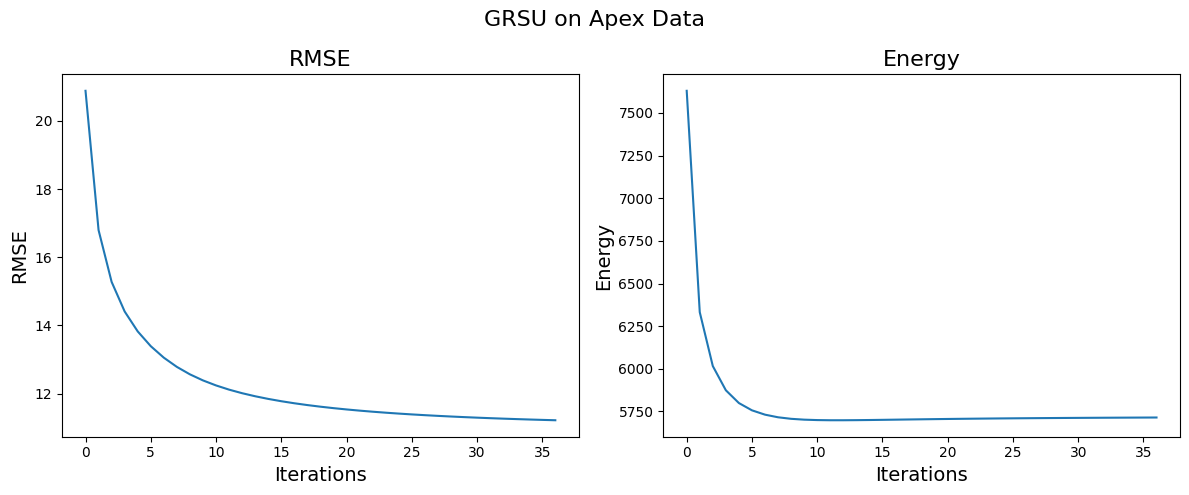

In [88]:
# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 11.208067044225308
# Best alpha: 20
# Best lambda: 1
# Best gamma: 100.0
# Best rho: 10.0
# RMSE: 11.208067044225308
#  SAD: 40.76096097652306

# Actual Run
A_GRSU_apex, S_GRSU_apex, A_GRSU_RMSE_apex, S_GRSU_RMSE_apex = run_unmixing_pipeline_example(X = X_apex, A_gt = A_apex, S_gt = S_apex, 
                                                                                         N = samples, iters = iters, alpha = 20.0, lam = 1.0, gamma = 100.0, rho = 10.0, m_0 = 4, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on Apex Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_apex_RMSE, GRSU_apex_energy, __, __ = run_unmixing_pipeline_example(X = X_apex, A_gt = A_apex, S_gt = S_apex, 
                                                                        N = samples, iters = iters, alpha = 20.0, lam = 1.0, gamma = 100.0, rho = 10.0, m_0 = 4, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Apex Data", 
                                                                        prep = None, array_plots = True)

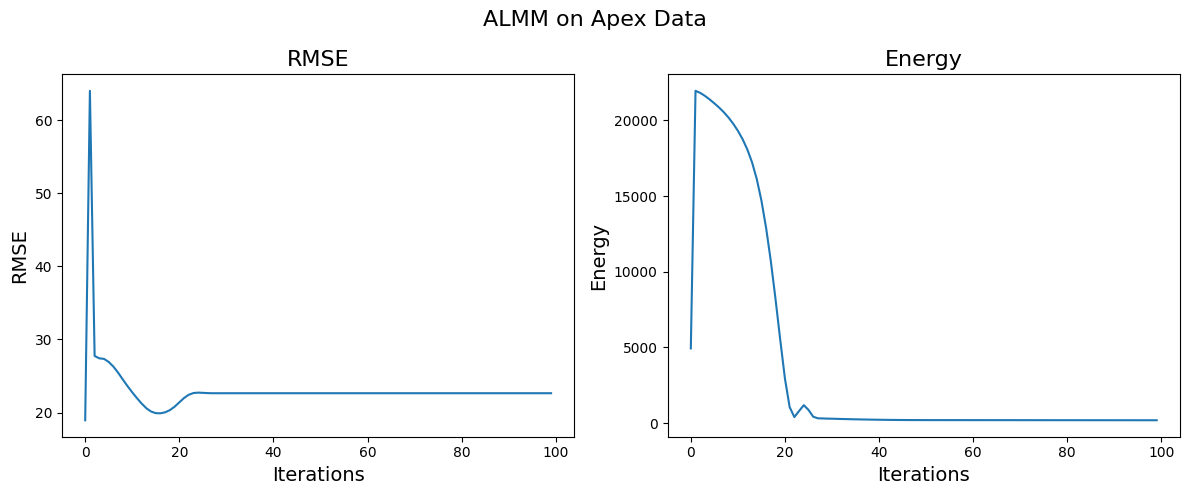

In [89]:
# ALMM
# ==========
# Best RMSE: 22.64309411402312
# Best alpha: 5.499999999999999e-07
# Best beta: 0.0055
# Best gamma: 5.499999999999999e-07
# Best eta: 5.499999999999999e-07

best_alpha = 5.5e-7
best_beta = 0.0055
best_gamma = 5.5e-7
best_eta = 5.5e-7

# Actual Run
E_ALMM_apex, A_ALMM_apex, T_ALMM_apex, B_ALMM_apex = algo_2_almm_optimized(X = X_apex, S = S_apex, A_gt = A_apex, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on Apex Data", array_plots = False)

# Error and Energy arrays
ALMM_apex_RMSE, ALMM_apex_energy, __, __ = algo_2_almm_optimized(X = X_apex, S = S_apex, A_gt = A_apex, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Apex Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (4, 2500)
Final End-member Matrix Shape: (285, 4)
Final Abundance RMSE: 13.062906030349808
Final Endmember SAD: 35.67411895055509


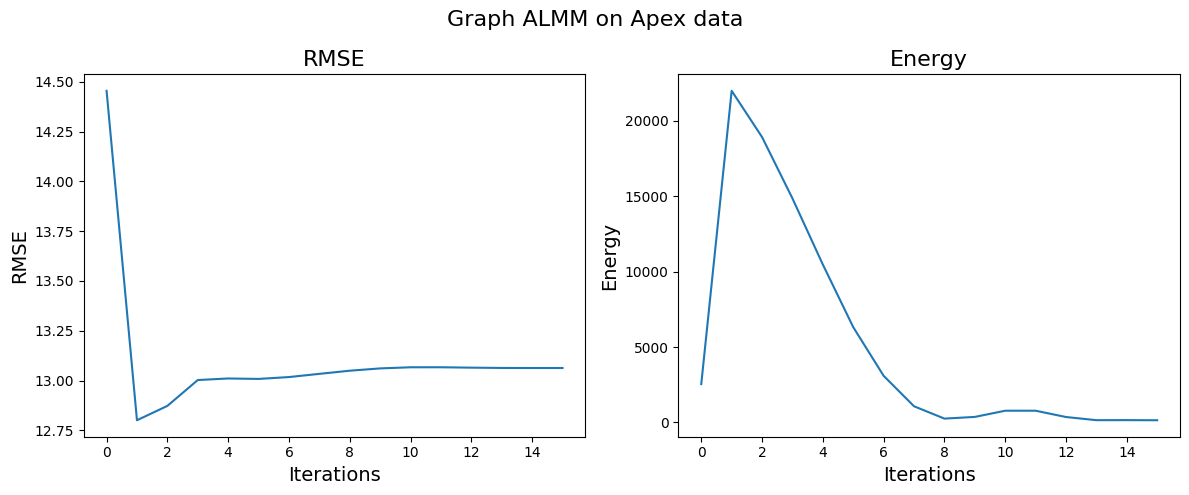

In [90]:
# Graph ALMM (RMSE)
# ==========
# Best RMSE: 13.062906030349808
# Best alpha: 0.0055
# Best M_total: 30.0
# Best xi: 1
# Best label: OH

alpha_0 = 0.0055
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 1

# Actual Run
A_graph_almm_apex, S_graph_almm_apex, A_rmse_graph_almm_apex, S_rmse_graph_almm_apex = run_unmixing_pipeline_example2(X = X_apex, A_gt = A_apex, S_gt = S_apex, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 30.0, m_0 = 4, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on Apex data", array_plots = False)

# Error and Energy arrays
graph_almm_apex_RMSE, graph_almm_apex_energy, __, __ = run_unmixing_pipeline_example2(X = X_apex, A_gt = A_apex, S_gt = S_apex, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 30.0, m_0 = 4, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Apex data", array_plots = True)

#### Plots

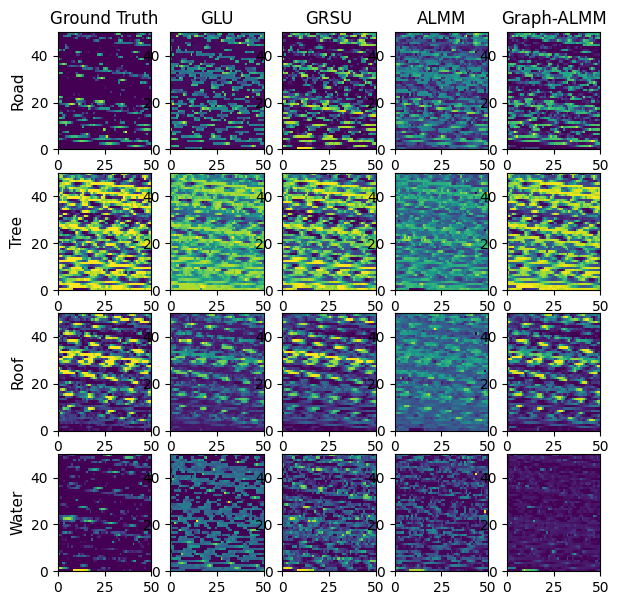

In [91]:
class_names = ['Road', 'Tree', 'Roof', 'Water']
algo_names = ['Ground Truth', 'GLU', 'GRSU', 'ALMM', 'Graph-ALMM']

image_plotting(A_gt = A_apex, A_f_GLU = A_GLU_apex, A_f_GRSU = A_GRSU_apex, A_f_ALMM = A_ALMM_apex, A_f_Graph_ALMM = A_graph_almm_apex, 
               k = 4, col = 5, patch_size = 50, class_names = class_names, algo_names = algo_names)

#### Error and Energy plots

In [92]:
# Define data arrays of tuples
apex_RMSE = [
    ("GLU", A_GLU_RMSE_apex),
    ("GRSU", GRSU_apex_RMSE),
    ("ALMM", ALMM_apex_RMSE),
    ("Graph-ALMM", graph_almm_apex_RMSE),
]

apex_energy = [
    ("GLU", GLU_apex_energy),
    ("GRSU", GRSU_apex_energy),
    ("ALMM", ALMM_apex_energy),
    ("Graph-ALMM", graph_almm_apex_energy),
]

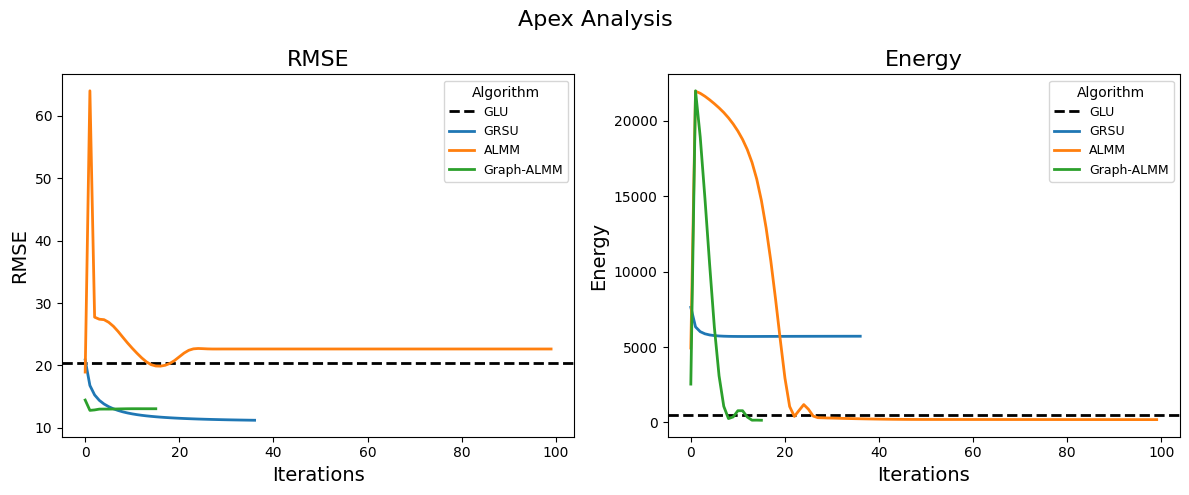

In [93]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = apex_RMSE, Energy_data = apex_energy, title_0 = "Apex Analysis")

### Nonlinear

#### Tests

##### Param Test results

In [ ]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 27.072536191060763
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 27.072536191060763
#  SAD: 15.474725816753601


# GLU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 42.48586925173367
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 27.072536191060763
#  SAD: 15.413333060672905

# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 1.22317847208902
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 1.22317847208902
#  SAD: 18.95837944301178

# GLU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 20.101762607090624
# Best alpha: 100
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 1.22317847208902
#  SAD: 18.878584135001603


# GRSU (OH) (RMSE)
# ==========
# Best RMSE: 12.33336375953646
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 10.0
# RMSE: 12.33336375953646
#  SAD: 16.153639067076753


# GRSU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 28.487002826613214
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 10.0
# RMSE: 12.33336375953646
#  SAD: 16.153639067076753

# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 1.1966843985873439
# Best alpha: 20
# Best lambda: 5000
# Best gamma: 100.0
# Best rho: 0.01
# RMSE: 1.1966843985873439
#  SAD: 18.918320717857043

# GRSU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 20.07700339747558
# Best alpha: 100
# Best lambda: 5000
# Best gamma: 100.0
# Best rho: 0.01
# RMSE: 1.1984390910008589
#  SAD: 18.87856430647472


# ALMM
# ==========
# Best RMSE: 13.772709833998931
# Best alpha: 5.499999999999999e-07
# Best beta: 5.4999999999999995e-05
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055


# Graph ALMM (RMSE)
# ==========
# Best RMSE: 0.6284109844944475
# Best alpha: 5.499999999999999e-07
# Best M_total: 40.0
# Best xi: 100
# Best label: Exact


# Graph ALMM (RMSE + SAD)
# ==========
# Best RMSE + SAD: 17.971876845849714
# Best alpha: 5.499999999999999e-07
# Best M_total: 40.0
# Best xi: 100
# Best label: Exact

##### Runs

In [94]:
# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 1.22317847208902
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 1.22317847208902
#  SAD: 18.95837944301178

# Actual Run
A_GLU_nl, S_GLU_nl, A_GLU_RMSE_nl, S_GLU_RMSE_nl = run_unmixing_pipeline_example(X = X_nl_flat, A_gt = A_gt_nl, S_gt = S_gt_nl, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Nonlinear Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_nl_energy, __, __, __ = run_unmixing_pipeline_example(X = X_nl_flat, A_gt = A_gt_nl, S_gt = S_gt_nl, 
                                                                                         N = samples, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = False, OH_labels = False, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Nonlinear Data", 
                                                                                         prep = None, array_plots = True)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 1.22317847208902
Final Endmember SAD: 18.95837944301178


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 1.1966843985873439
Final Endmember SAD: 18.918320717857043


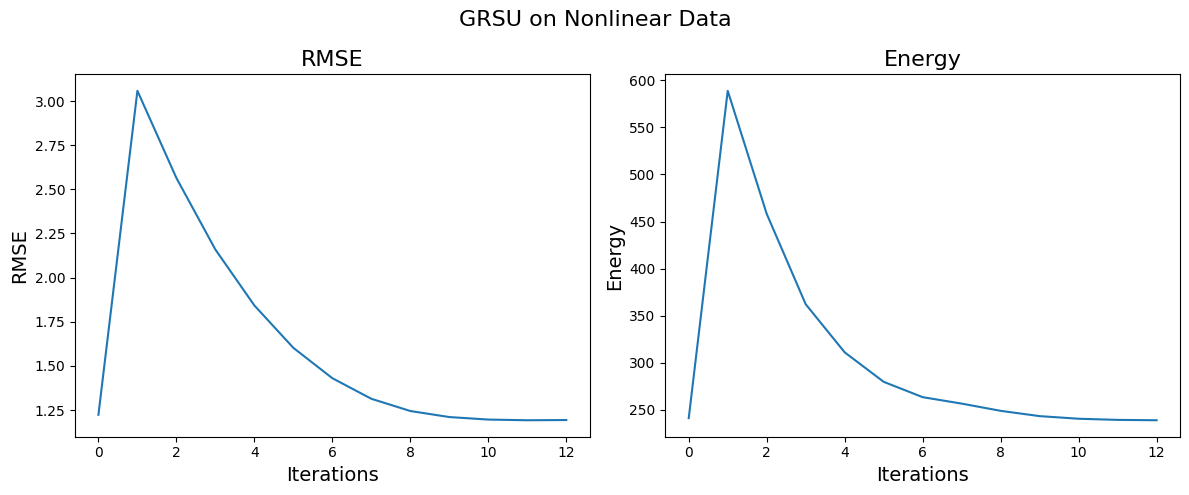

In [95]:
# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 1.1966843985873439
# Best alpha: 20
# Best lambda: 5000
# Best gamma: 100.0
# Best rho: 0.01
# RMSE: 1.1966843985873439
#  SAD: 18.918320717857043

# Actual Run
A_GRSU_nl, S_GRSU_nl, A_GRSU_RMSE_nl, S_GRSU_RMSE_nl = run_unmixing_pipeline_example(X = X_nl_flat, A_gt = A_gt_nl, S_gt = S_gt_nl, 
                                                                                         N = samples, iters = iters, alpha = 20.0, lam = 5000.0, gamma = 100.0, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on Nonlinear Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_nl_RMSE, GRSU_nl_energy, __, __ = run_unmixing_pipeline_example(X = X_nl_flat, A_gt = A_gt_nl, S_gt = S_gt_nl, 
                                                                        N = samples, iters = iters, alpha = 20.0, lam = 5000.0, gamma = 100.0, rho = 0.01, m_0 = 2, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Nonlinear Data", 
                                                                        prep = None, array_plots = True)

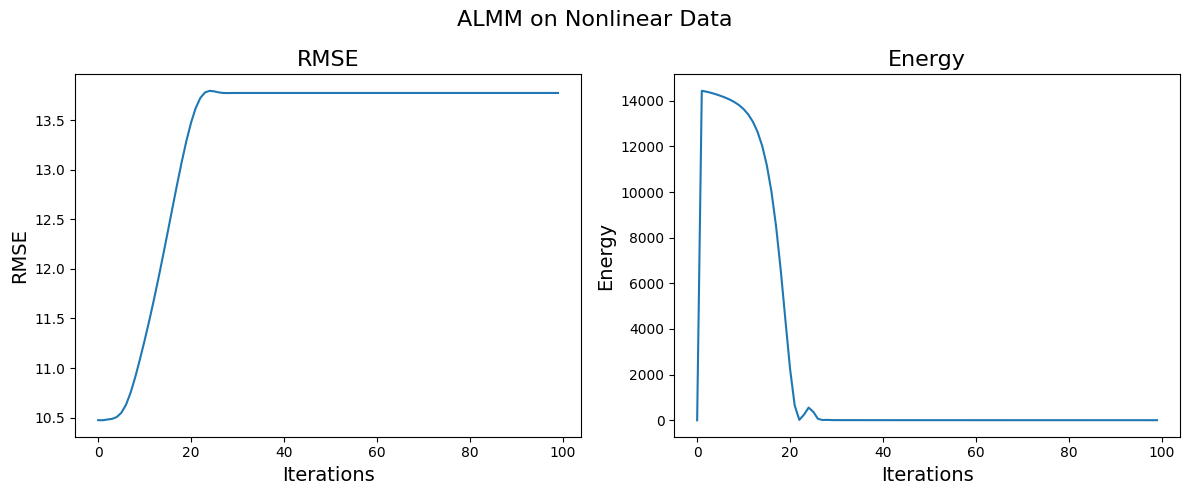

In [96]:
# ALMM
# ==========
# Best RMSE: 13.772709833998931
# Best alpha: 5.499999999999999e-07
# Best beta: 5.4999999999999995e-05
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055

best_alpha = 5.5e-7
best_beta = 5.5e-5
best_gamma = 5.5e-7
best_eta = 0.0055

# Actual Run
E_ALMM_nl, A_ALMM_nl, T_ALMM_nl, B_ALMM_nl = algo_2_almm_optimized(X = X_nl_flat, S = S_gt_nl, A_gt = A_gt_nl, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on Nonlinear Data", array_plots = False)

# Error and Energy arrays
ALMM_nl_RMSE, ALMM_nl_energy, __, __ = algo_2_almm_optimized(X = X_nl_flat, S = S_gt_nl, A_gt = A_gt_nl, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Nonlinear Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 2500)
Final End-member Matrix Shape: (30, 2)
Final Abundance RMSE: 0.6284109844944475
Final Endmember SAD: 17.343465861355266


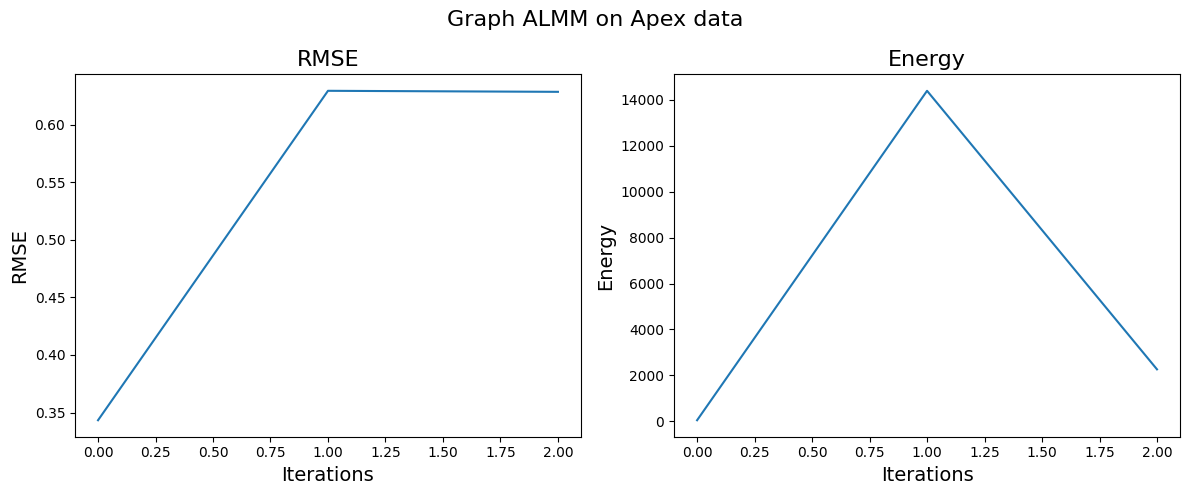

In [97]:
# Graph ALMM (RMSE)
# ==========
# Best RMSE: 0.6284109844944475
# Best alpha: 5.499999999999999e-07
# Best M_total: 40.0
# Best xi: 100
# Best label: Exact

alpha_0 = 5.5e-7
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 100

# Actual Run
A_graph_almm_nl, S_graph_almm_nl, A_rmse_graph_almm_nl, S_rmse_graph_almm_nl = run_unmixing_pipeline_example2(X = X_nl_flat, A_gt = A_gt_nl, S_gt = S_gt_nl, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on Apex data", array_plots = False)

# Error and Energy arrays
graph_almm_nl_RMSE, graph_almm_nl_energy, __, __ = run_unmixing_pipeline_example2(X = X_nl_flat, A_gt = A_gt_nl, S_gt = S_gt_nl, N = samples, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 40.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = False, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Apex data", array_plots = True)

#### Plots

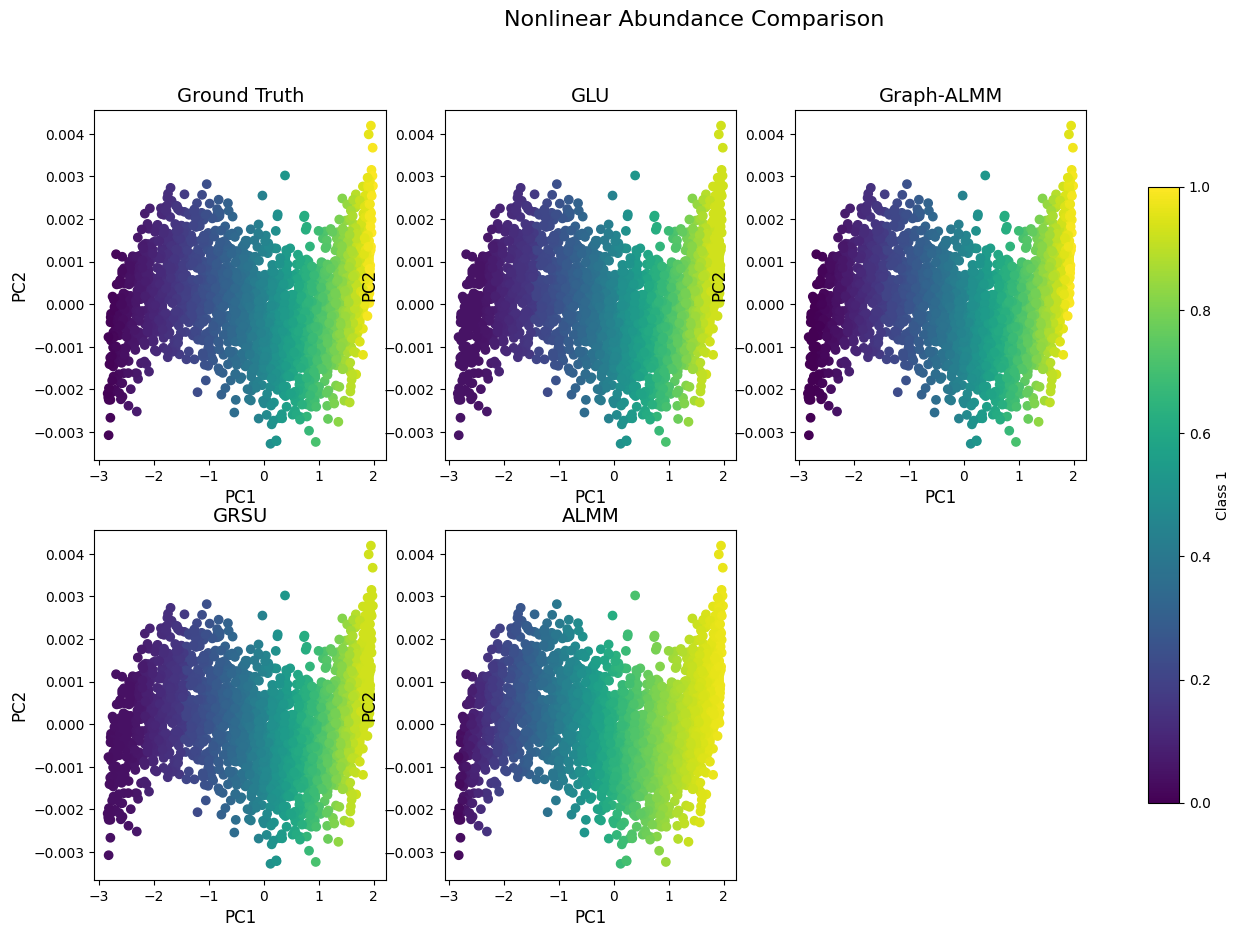

In [98]:
corr = np.corrcoef(A_ALMM_nl[0], A_gt_nl[0])[0, 1]
A_ALMM_nl_fixed = 1 - A_ALMM_nl if corr < 0 else A_ALMM_nl

abundance_plotting(X = X_nl_flat, A_gt = A_gt_nl, 
                   A_f_GLU = A_GLU_nl, A_f_GRSU = A_GRSU_nl, A_f_ALMM = A_ALMM_nl_fixed, A_f_Graph_ALMM = A_graph_almm_nl, 
                   title = 'Nonlinear Abundance Comparison', color_title = 'Class 1')

#### Error and Energy plots

In [99]:
# Define data arrays of tuples
nl_RMSE = [
    ("GLU", A_GLU_RMSE_nl),
    ("GRSU", GRSU_nl_RMSE),
    ("ALMM", ALMM_nl_RMSE),
    ("Graph-ALMM", graph_almm_nl_RMSE),
]

nl_energy = [
    ("GLU", GLU_nl_energy),
    ("GRSU", GRSU_nl_energy),
    ("ALMM", ALMM_nl_energy),
    ("Graph-ALMM", graph_almm_nl_energy),
]

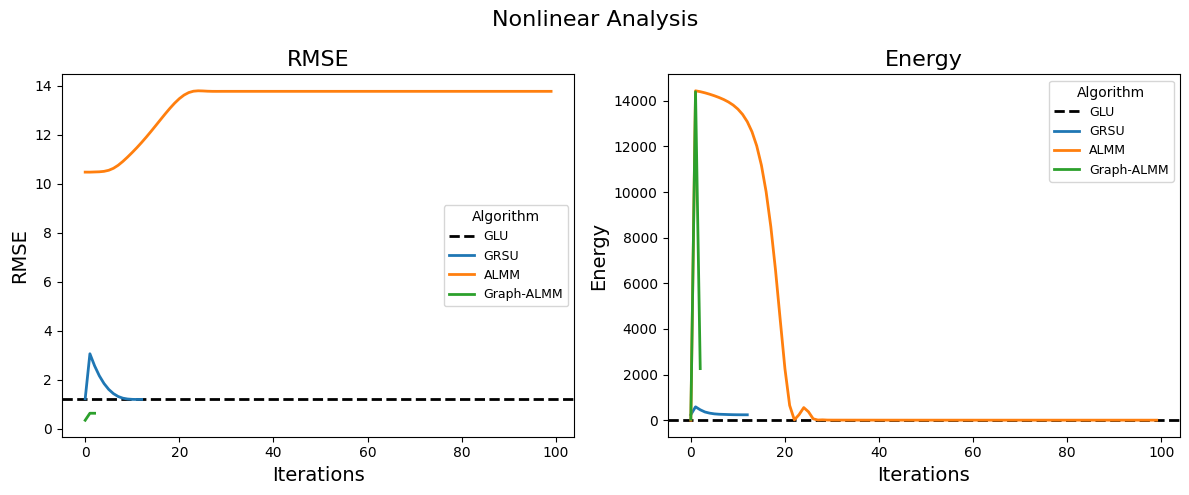

In [100]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = nl_RMSE, Energy_data = nl_energy, title_0 = "Nonlinear Analysis")

### Linear

#### Tests

##### Param Test results

In [ ]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 21.39481515797743
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 21.39481515797743
#  SAD: 3.046165838405078


# GLU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 24.440980996382507
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 21.39481515797743
#  SAD: 3.046165838405078

# GLU (Exact) (RMSE)
# ==========
# Best RMSE: 23.414307995809217
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 23.414307995809217
#  SAD: 3.8965401969239424

# GLU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 26.91827070290401
# Best alpha: 20
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 23.414307995809217
#  SAD: 3.5039627070947925


# GRSU (OH) (RMSE)
# ==========
# Best RMSE: 3.5613649007802097
# Best alpha: 20
# Best lambda: 10
# Best gamma: 0.01
# Best rho: 0.1
# RMSE: 3.5613649007802097
#  SAD: 3.817938855168785


# GRSU (OH) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 6.017638007729815
# Best alpha: 10
# Best lambda: 10
# Best gamma: 0.01
# Best rho: 0.1
# RMSE: 3.6447623809258936
#  SAD: 2.372875626803921

# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 2.544210846845358
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 2.544210846845358
#  SAD: 1.3396418043495149

# GRSU (Exact) (RMSE + SAD)
# ==========
# Best RMSE + SAD: 3.8838526511948728
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 2.544210846845358
#  SAD: 1.3396418043495149


# ALMM
# ==========
# Best RMSE: 12.21671234230718
# Best alpha: 0.0005499999999999999
# Best beta: 0.0055
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055


# Graph ALMM (RMSE)
# ==========
# Best RMSE: 9.921094750967884
# Best alpha: 0.0055
# Best M_total: 32.0
# Best xi: 10
# Best label: OH


# Graph ALMM (RMSE + SAD)
# ==========
# Best RMSE + SAD: 11.830912490300184
# Best alpha: 0.0055
# Best M_total: 32.0
# Best xi: 100
# Best label: OH

##### Runs

In [102]:
# GLU (OH) (RMSE)
# ==========
# Best RMSE: 21.39481515797743
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 21.39481515797743
#  SAD: 3.046165838405078


# Actual Run
A_GLU_linear, S_GLU_linear, A_GLU_RMSE_linear, S_GLU_RMSE_linear = run_unmixing_pipeline_example(X = X_linear, A_gt = A_linear, S_gt = S_linear, 
                                                                                         N = samples_linear, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Nonlinear Data", 
                                                                                         prep = None, array_plots = False)

# Energy
GLU_linear_energy, __, __, __ = run_unmixing_pipeline_example(X = X_linear, A_gt = A_linear, S_gt = S_linear, 
                                                                                         N = samples_linear, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = False, OH_labels = True, GRSU_bool = False, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GLU on Nonlinear Data", 
                                                                                         prep = None, array_plots = True)


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GLU Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 21.39481515797743
Final Endmember SAD: 3.046165838405078


Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running GRSU (and GLU) Unmixing on Exact...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 2.544210846845358
Final Endmember SAD: 1.3396418043495149


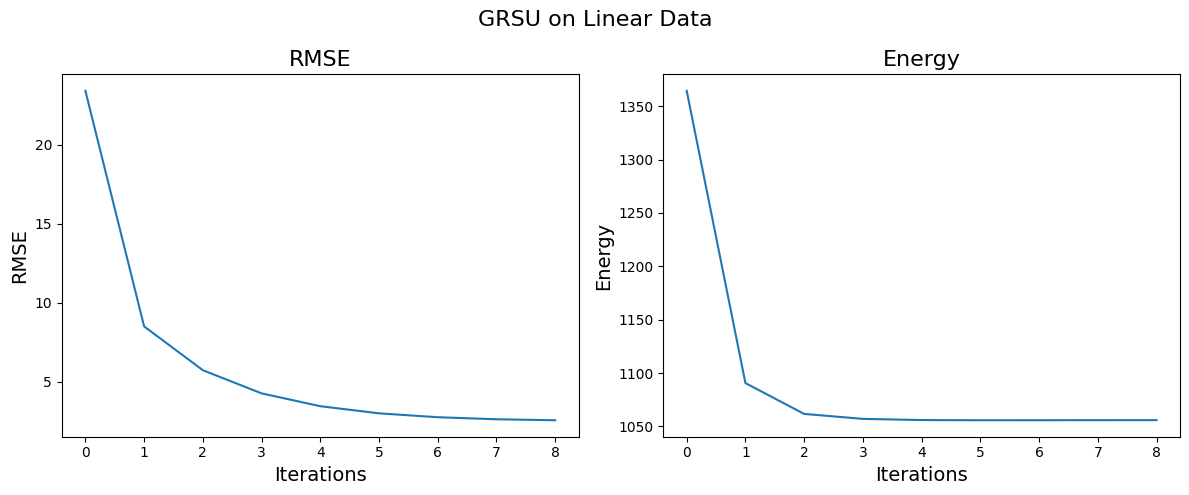

In [103]:
# GRSU (Exact) (RMSE)
# ==========
# Best RMSE: 2.544210846845358
# Best alpha: 10
# Best lambda: 1
# Best gamma: 0.01
# Best rho: 0.01
# RMSE: 2.544210846845358
#  SAD: 1.3396418043495149

# Actual Run
A_GRSU_linear, S_GRSU_linear, A_GRSU_RMSE_linear, S_GRSU_RMSE_linear = run_unmixing_pipeline_example(X = X_linear, A_gt = A_linear, S_gt = S_linear, 
                                                                                         N = samples_linear, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                                         print_bool = True, OH_labels = False, GRSU_bool = True, 
                                                                                         A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "GRSU on Linear Data", 
                                                                                         prep = None, array_plots = False)

# Error and Energy arrays
GRSU_linear_RMSE, GRSU_linear_energy, __, __ = run_unmixing_pipeline_example(X = X_linear, A_gt = A_linear, S_gt = S_linear, 
                                                                        N = samples_linear, iters = iters, alpha = 10.0, lam = 1.0, gamma = 0.01, rho = 0.01, m_0 = 2, 
                                                                        print_bool = False, OH_labels = False, GRSU_bool = True, 
                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "GRSU on Linear Data", 
                                                                        prep = None, array_plots = True)

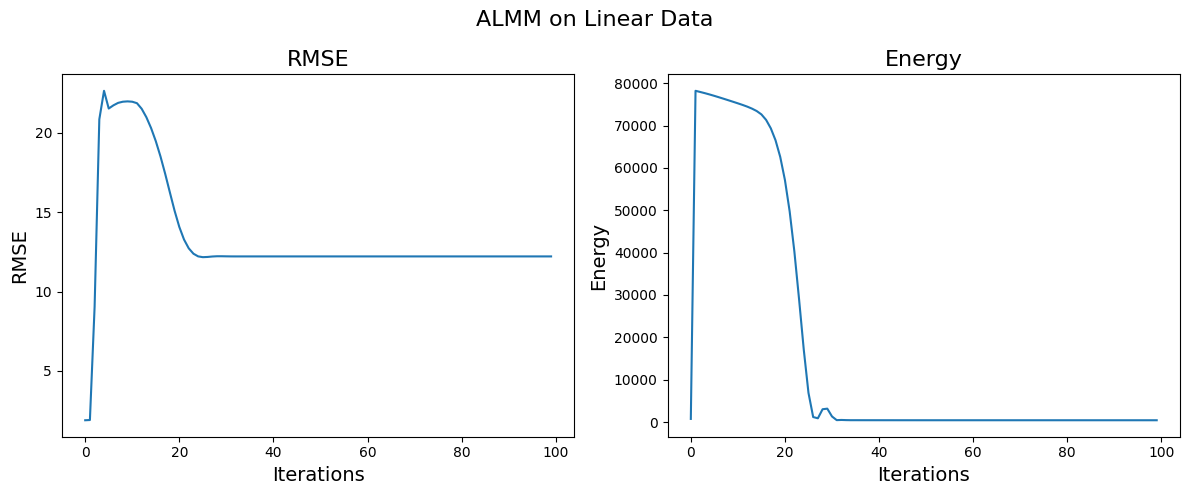

In [104]:
# ALMM
# ==========
# Best RMSE: 12.21671234230718
# Best alpha: 0.0005499999999999999
# Best beta: 0.0055
# Best gamma: 5.499999999999999e-07
# Best eta: 0.0055

best_alpha = 0.00055
best_beta = 0.0055
best_gamma = 5.5e-7
best_eta = 0.0055

# Actual Run
E_ALMM_linear, A_ALMM_linear, T_ALMM_linear, B_ALMM_linear = algo_2_almm_optimized(X = X_linear, S = S_linear, A_gt = A_linear, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "ALMM on Linear Data", array_plots = False)

# Error and Energy arrays
ALMM_linear_RMSE, ALMM_linear_energy, __, __ = algo_2_almm_optimized(X = X_linear, S = S_linear, A_gt = A_linear, 
                                                                            alpha = best_alpha, beta = best_beta, gamma = best_gamma, eta = best_eta, 
                                                                            maxIter = iters,
                                                                            A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "ALMM on Linear Data", array_plots = True)

Building initial graph for Active Learning...
Running Active Learning...
Extracting training data and generating pseudo-labels...
Running Graph ALMM Unmixing on OH...
Pipeline Complete!

Final Abundance Map Shape: (2, 2000)
Final End-member Matrix Shape: (300, 2)
Final Abundance RMSE: 9.921094750967884
Final Endmember SAD: 4.898980416054546


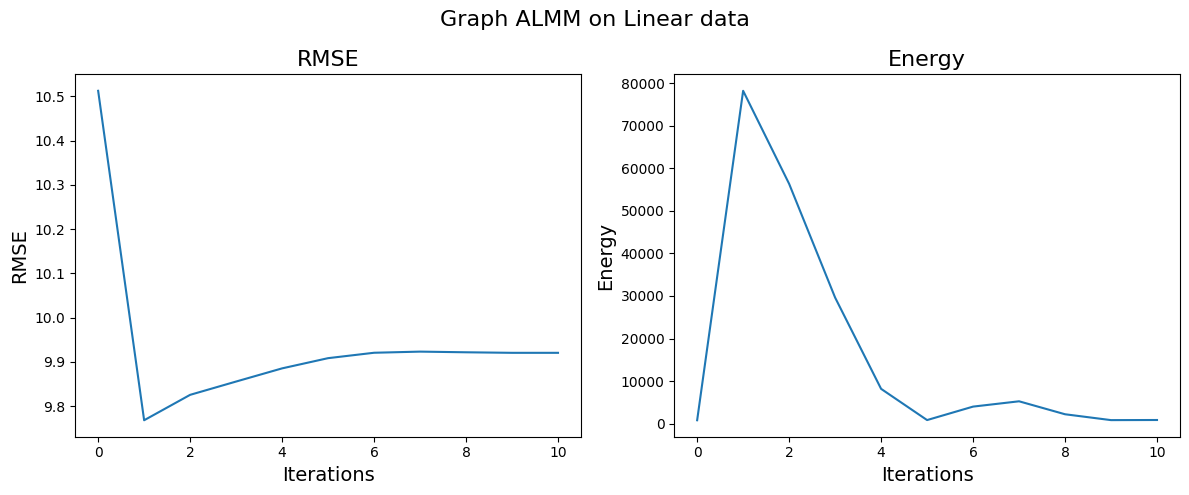

In [105]:
# Graph ALMM (RMSE)
# ==========
# Best RMSE: 9.921094750967884
# Best alpha: 0.0055
# Best M_total: 32.0
# Best xi: 10
# Best label: OH

alpha_0 = 0.0055
beta_0 = (1e-3 + 1e-2)/2
gamma_0 = (1e-3 + 1e-2)/2
eta_0 = (1e-3 + 1e-2)/2
xi_0 = 10

# Actual Run
A_graph_almm_linear, S_graph_almm_linear, A_rmse_graph_almm_linear, S_rmse_graph_almm_linear = run_unmixing_pipeline_example2(X = X_linear, A_gt = A_linear, S_gt = S_linear, N = samples_linear, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 32.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = True, 
                                                                                                                        A_error = False, RMSE_plot = False, Energy_plot = False, title_0 = "Graph ALMM on Linear data", array_plots = False)

# Error and Energy arrays
graph_almm_linear_RMSE, graph_almm_linear_energy, __, __ = run_unmixing_pipeline_example2(X = X_linear, A_gt = A_linear, S_gt = S_linear, N = samples_linear, 
                                                                                                                        alpha = alpha_0, beta = beta_0, gamma = gamma_0, eta = eta_0, maxIter = iters, 
                                                                                                                        M_total_0 = 32.0, m_0 = 2, xi_0 = xi_0, 
                                                                                                                        OH_labels = True, print_bool = False, 
                                                                                                                        A_error = False, RMSE_plot = True, Energy_plot = True, title_0 = "Graph ALMM on Linear data", array_plots = True)

#### Plots

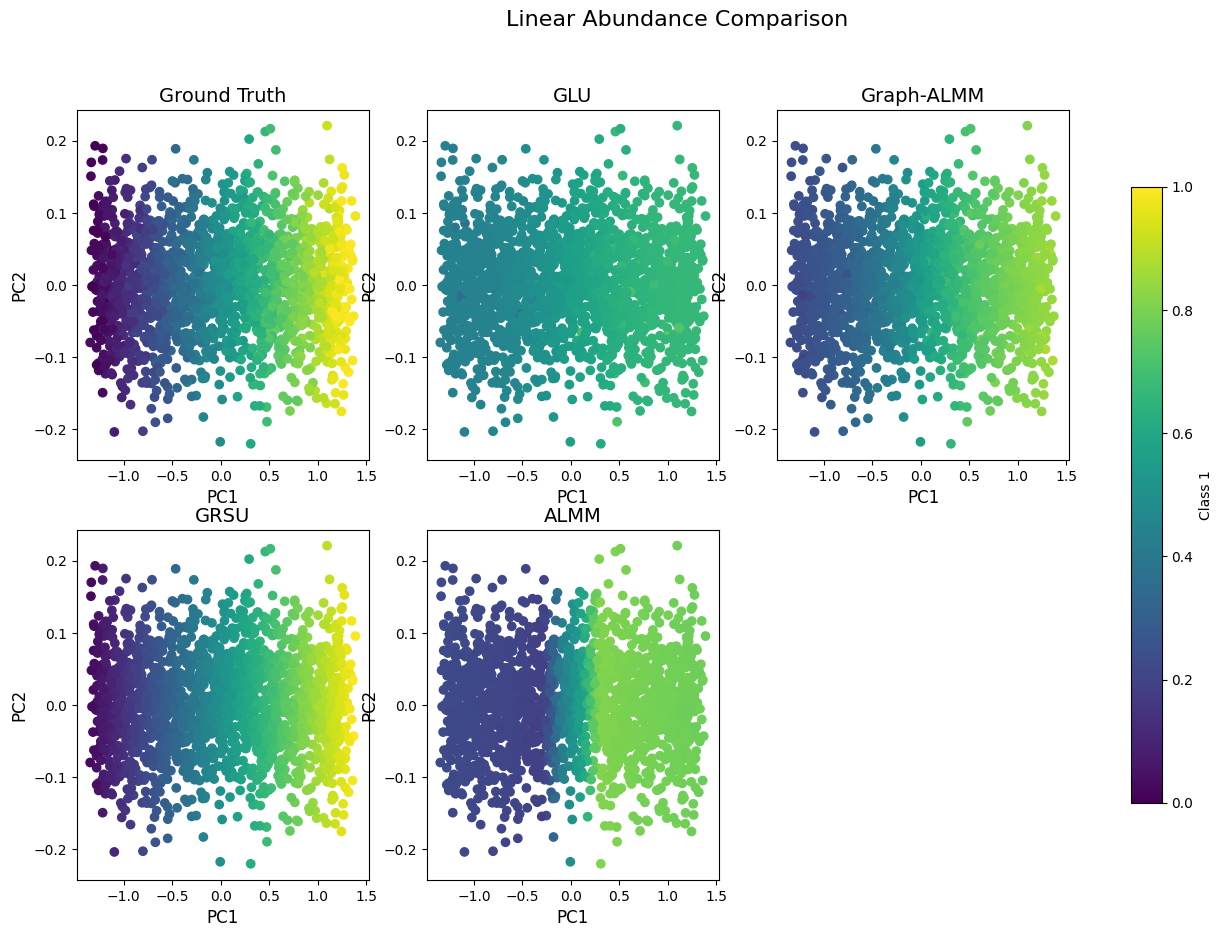

In [106]:
corr = np.corrcoef(A_ALMM_linear[0], A_linear[0])[0, 1]
A_ALMM_linear_fixed = 1 - A_ALMM_linear if corr < 0 else A_ALMM_linear

abundance_plotting(X = X_linear, A_gt = A_linear, 
                   A_f_GLU = A_GLU_linear, A_f_GRSU = A_GRSU_linear, A_f_ALMM = A_ALMM_linear_fixed, A_f_Graph_ALMM = A_graph_almm_linear, 
                   title = 'Linear Abundance Comparison', color_title = 'Class 1')

#### Error and Energy plots

In [107]:
# Define data arrays of tuples
linear_RMSE = [
    ("GLU", A_GLU_RMSE_linear),
    ("GRSU", GRSU_linear_RMSE),
    ("ALMM", ALMM_linear_RMSE),
    ("Graph-ALMM", graph_almm_linear_RMSE),
]

linear_energy = [
    ("GLU", GLU_linear_energy),
    ("GRSU", GRSU_linear_energy),
    ("ALMM", ALMM_linear_energy),
    ("Graph-ALMM", graph_almm_linear_energy),
]

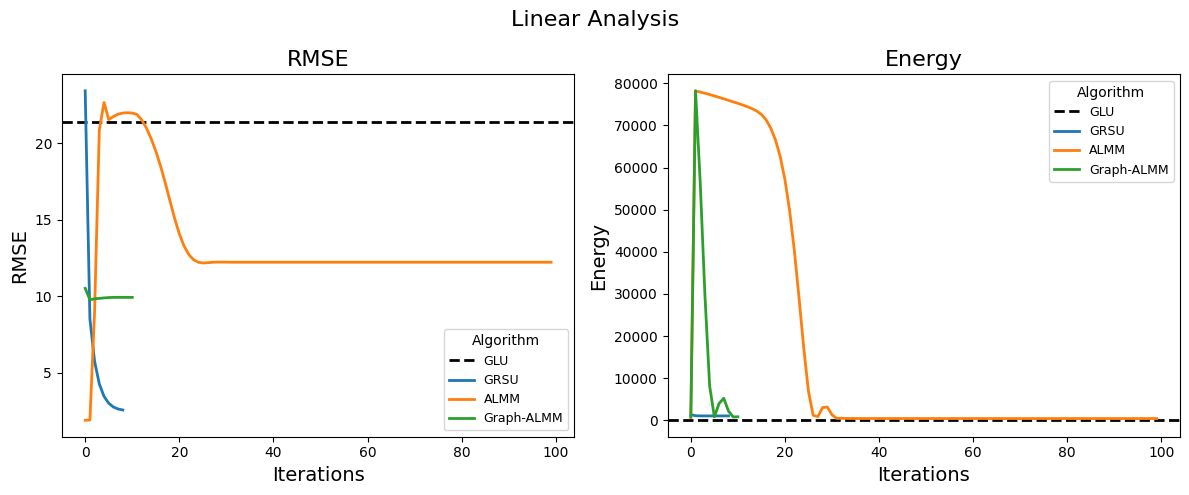

In [108]:
# Plot 
graph_plotter_multiple(A_error = False, RMSE_plot = True, Energy_plot = True, 
                       A_error_data = [], RMSE_data = linear_RMSE, Energy_data = linear_energy, title_0 = "Linear Analysis")

### RMSE table

In [111]:
# Calculate RMSE for ALMM
A_ALMM_RMSE_urban = RMSE(A_ALMM_urban, A_urban)
A_ALMM_RMSE_samson = RMSE(A_ALMM_samson, A_samson)
A_ALMM_RMSE_jasper = RMSE(A_ALMM_jasper, A_jasper)
A_ALMM_RMSE_apex = RMSE(A_ALMM_apex, A_apex)

A_ALMM_RMSE_nl = RMSE(A_ALMM_nl, A_gt_nl)
A_ALMM_RMSE_linear = RMSE(A_ALMM_linear, A_linear)

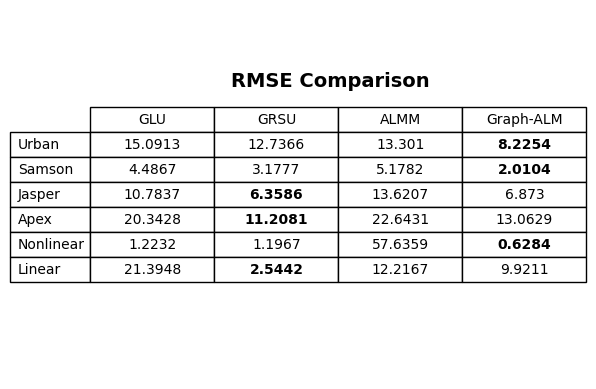

In [112]:


data = np.array([
    [np.round(A_GLU_RMSE_urban, 4), np.round(A_GRSU_RMSE_urban, 4), np.round(A_ALMM_RMSE_urban, 4), np.round(A_rmse_graph_almm_urban, 4)],
    [np.round(A_GLU_RMSE_samson, 4), np.round(A_GRSU_RMSE_samson, 4), np.round(A_ALMM_RMSE_samson, 4), np.round(A_rmse_graph_almm_samson, 4)],
    [np.round(A_GLU_RMSE_jasper, 4), np.round(A_GRSU_RMSE_jasper, 4), np.round(A_ALMM_RMSE_jasper, 4), np.round(A_rmse_graph_almm_jasper, 4)],
    [np.round(A_GLU_RMSE_apex, 4), np.round(A_GRSU_RMSE_apex, 4), np.round(A_ALMM_RMSE_apex, 4), np.round(A_rmse_graph_almm_apex, 4)],
    [np.round(A_GLU_RMSE_nl, 4), np.round(A_GRSU_RMSE_nl, 4), np.round(A_ALMM_RMSE_nl, 4), np.round(A_rmse_graph_almm_nl, 4)],
    [np.round(A_GLU_RMSE_linear, 4), np.round(A_GRSU_RMSE_linear, 4), np.round(A_ALMM_RMSE_linear, 4), np.round(A_rmse_graph_almm_linear, 4)]
])

headers = ["GLU", "GRSU", "ALMM", "Graph-ALM"]
row_headers = ["Urban", "Samson", "Jasper", "Apex", "Nonlinear", "Linear"]

fig, ax = plt.subplots()
ax.axis("off")  # hide the plot axes, just want the table

table = ax.table(
    cellText=data,
    colLabels=headers,
    rowLabels=row_headers,
    cellLoc="center",
    loc="center"
)

# bold the min value in each row
for row_idx, row in enumerate(data):
    min_col = np.argmin(row)
    cell = table[row_idx + 1, min_col]  # +1 because row 0 is the header
    cell.set_text_props(weight="bold")

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

fig.suptitle("RMSE Comparison", fontsize=14, fontweight="bold", y = 0.75)

plt.savefig("plot_images/RMSE_table_HSI.png", dpi=300, bbox_inches="tight")